# Factoring and period finding

In [2]:
%pip install qiskit
%pip install qiskit-aer

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
from qiskit import QuantumCircuit
import sys
np.set_printoptions(threshold=sys.maxsize)
import pandas as pd
from fractions import Fraction

In [4]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

Directly prepare the Quantum state, instead of using modular exponentiation

In [5]:
def get_coeffs(x, N, n_q, n_count):
    vec = np.zeros(2**n_q)
    base = 1
    for i in range(2**n_count):
        s1 = np.binary_repr(i,n_count)
        mod2 = np.mod(base,N)
        base = mod2*x
        s2 = np.binary_repr(mod2,n_q-n_count) #IMPORTATNT that n_q-n_count must be >= log2(N)
        print(i,mod2,s1,s2)
        vec[int(s2+s1,2)] = 1
    return vec

Quantum Fourier transform

In [6]:
def qft_dagger(n):
    """n-qubit QFTdagger the first n qubits in circ"""
    qc = QuantumCircuit(n)
    # Don't forget the Swaps!
    for qubit in range(n//2):
        qc.swap(qubit, n-qubit-1)
    for j in range(n):
        for m in range(j):
            qc.cp(-np.pi/float(2**(j-m)), m, j)
        qc.h(j)
    qc.name = "QFT†"
    return qc

## Example: x=3, N=15

In [1]:
x = 3
N = 35
n_q = 14 # total number of Qubits (QFT_register + a**i_register)
n_count = 6  # number of qubits of QFT_register

In [54]:
vec = get_coeffs(x, N, n_q, n_count)

0 1 0000 0000000001
1 3 0001 0000000011
2 9 0010 0000001001
3 27 0011 0000011011
4 11 0100 0000001011
5 33 0101 0000100001
6 29 0110 0000011101
7 17 0111 0000010001
8 16 1000 0000010000
9 13 1001 0000001101
10 4 1010 0000000100
11 12 1011 0000001100
12 1 1100 0000000001
13 3 1101 0000000011
14 9 1110 0000001001
15 27 1111 0000011011


In [55]:
vec = np.multiply(vec, 1/np.sqrt(2**n_count))
print(vec)

[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.25 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.25 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.25 0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.25 0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.25 0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.25 0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.25 0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.25 0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0. 

### Start simulation: (using i.e. Qiskit)

In [56]:
Q = QuantumCircuit(n_q,n_count)

In [57]:
Q.initialize(vec)

In [58]:
Q.append(qft_dagger(n_count),range(n_count))
Q.measure(range(n_count),range(n_count))
Q.draw(fold=-1)  # -1 means 'do not fold'

┌───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

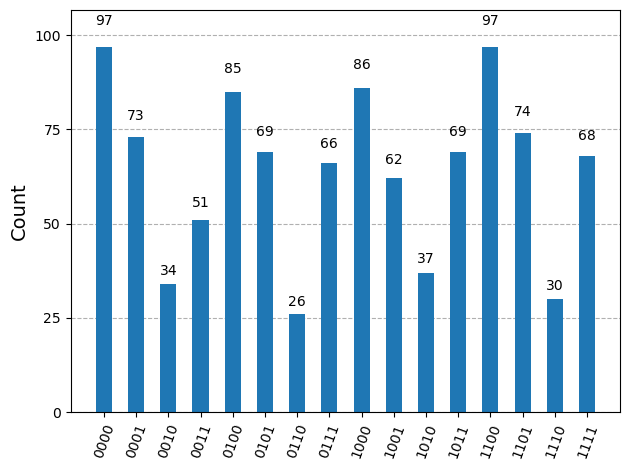

In [59]:
aer_sim = Aer.get_backend('aer_simulator')
t_qc = transpile(Q, aer_sim)
results = aer_sim.run(t_qc).result()
counts = results.get_counts()
plot_histogram(counts)

Compute the continuous fraction, and obtain from there the candidate factors

In [45]:
rows, measured_phases = [], []
for output in counts:
    decimal = int(output, 2)  # Convert (base 2) string to decimal
    phase = decimal/(2**n_count)  # Find corresponding eigenvalue
    measured_phases.append(phase)
    # Add these values to the rows in our table:
    frac = Fraction(phase).limit_denominator(N)
    #rows.append([f"{output}(bin) = {decimal:>3}(dec)", f"{decimal}/{2**n_count} = {phase:.2f}",f"{frac.numerator}/{frac.denominator}", frac.denominator, np.gcd(x**(frac.denominator//2)-1, N), np.gcd(x**(frac.denominator//2)+1, N)])
    rows.append([f"{output}(bin) = {decimal:>3}(dec)", f"{frac.numerator}/{frac.denominator}", frac.denominator, np.gcd(x**(frac.denominator//2)-1, N), np.gcd(x**(frac.denominator//2)+1, N)])
# Print the rows in a table
#headers=["Register Output", "Phase", "Fraction", "Guess for r", "guess1","guess2"]
headers=["Register Output", "Fraction", "Guess for r", "guess1","guess2"]
df = pd.DataFrame(rows, columns=headers)
print(df)

           Register Output Fraction  Guess for r  guess1  guess2
0   001110(bin) =  14(dec)     7/32           32       5       1
1   100101(bin) =  37(dec)    11/19           19       1       7
2   111011(bin) =  59(dec)    12/13           13       7       5
3   101110(bin) =  46(dec)    23/32           32       5       1
4   000101(bin) =   5(dec)     1/13           13       7       5
5   110111(bin) =  55(dec)      6/7            7       1       7
6   000000(bin) =   0(dec)      0/1            1      35       1
7   100000(bin) =  32(dec)      1/2            2       1       1
8   010000(bin) =  16(dec)      1/4            4       1       5
9   101010(bin) =  42(dec)    21/32           32       5       1
10  110110(bin) =  54(dec)    27/32           32       5       1
11  000111(bin) =   7(dec)      1/9            9       5       1
12  110000(bin) =  48(dec)      3/4            4       1       5
13  000010(bin) =   2(dec)     1/32           32       5       1
14  110101(bin) =  53(dec

In [21]:
print(2**(13)%35)

2
